# Customer Churn Prediction


##1. Introduction

This project focuses on predicting customer churn using machine learning techniques.  
Customer churn refers to the phenomenon where customers stop doing business with a company.

The objective is to identify patterns and key factors that contribute to customer attrition, enabling businesses to take proactive actions to improve customer retention.



##2. Loading the dataset and libraries

In [1]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [2]:
df = pd.read_csv("Customer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


When visualizing the first rows of the dataset, the following can be observed:

- The presence of demographic variables such as gender, SeniorCitizen, and Partner
- Variables related to contracted services such as InternetService and TechSupport
- Billing-related variables such as MonthlyCharges and TotalCharges
- The target variable Churn, which indicates whether the customer left the service

##3. Exploratory Data Analysis (EDA)

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


The dataset contains approximately 7,043 records and 21 columns. It can be observed that:

- Most variables are of type object, indicating that they are categorical

- There are numerical variables such as tenure (int) and MonthlyCharges (float)

- The TotalCharges column appears as type object, which is inconsistent since it represents a numerical value

Additionally, all columns appear to be complete at first glance, although it will be necessary to validate whether there are hidden or improperly represented values

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Key Findings:**

- SeniorCitizen

The mean is approximately 0.16, indicating that around 16% of customers are senior citizens
It is an imbalanced variable, as most values are 0

- tenure

It ranges from 0 to 72 months
The median is 29 months, suggesting that half of the customers have been with the company for less than approximately 2.5 years
There is considerable dispersion in customer tenure

- MonthlyCharges

The average is approximately 64.76
The minimum value is 18.25 and the maximum is 118.75
The distribution appears wide, indicating different levels of consumption or service plans

Important Observation:

The TotalCharges variable does not appear in this summary, confirming that it is not being interpreted as numerical
This suggests the presence of incorrect values or data type issues

In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


**Results Validation**

After the conversion, null values are identified in the TotalCharges column.

This confirms that there were invalid data entries (for example, empty spaces) that prevented the column from being correctly interpreted as numerical.

In [8]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [9]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


**Analysis of Records with Null Values**

Records where TotalCharges is null are filtered.

Upon analyzing these cases, it can be observed that they generally correspond to customers with tenure = 0, meaning customers who have just joined and have not yet generated accumulated charges.

This suggests that the missing values are not random errors, but rather a logical consequence of the business behavior.

In [10]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

**Imputation of Null Values**

Null values in TotalCharges are replaced with 0.

This decision is justified because customers with tenure = 0 have not generated accumulated charges, so the logical value is 0.

This imputation preserves the consistency of the dataset without removing valuable information.

In [11]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**Post-Cleaning Validation**

It is verified that there are no longer any null values.

In [12]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


**The proportion of each class is calculated.**

Approximately:

- 73% of customers do not churn
- 27% of customers do churn

This confirms that the dataset is imbalanced, which is important to consider when training the model.

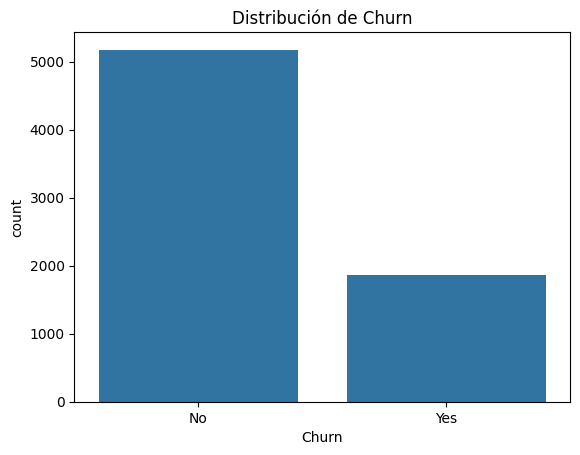

In [13]:
sns.countplot(data=df, x="Churn")
plt.title("Distribución de Churn")
plt.show()

The chart clearly shows the imbalance between the classes.

It can be observed that the "No" category dominates, which implies that a model could become biased toward this class if appropriate measures are not taken.

In [14]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

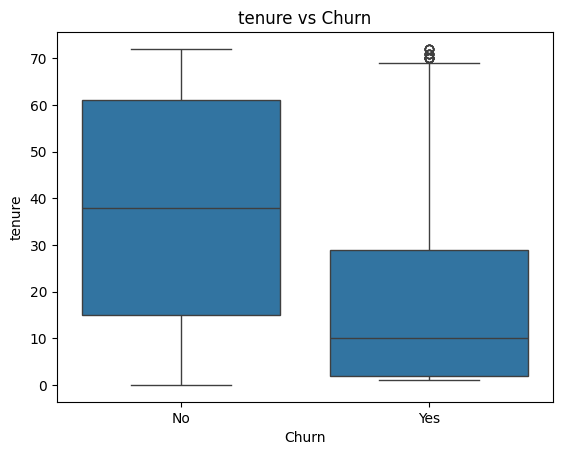

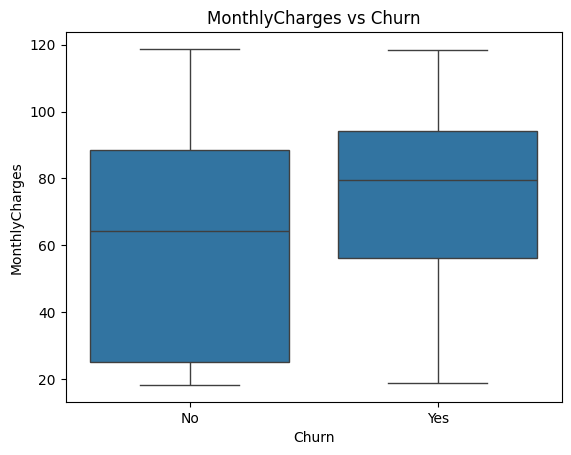

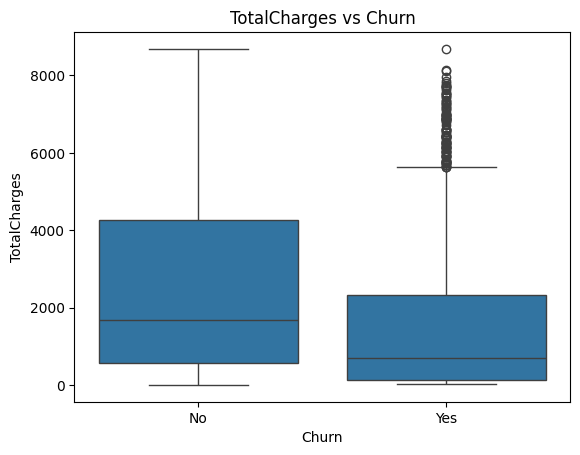

In [15]:
for col in num_cols:
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} vs Churn")
    plt.show()


**Relationship Between Numerical Variables and Churn**

Boxplots are used to analyze the distribution of numerical variables with respect to the target variable Churn.

Key Findings:

- tenure

Customers who do not churn have a significantly higher median (around 35–40 months)
Customers who churn have a median close to 10 months
Most customers who leave the service do so in the early stages

- MonthlyCharges

Customers who churn have a higher median in monthly charges
There is a higher concentration of large values in the churn group
This suggests that higher prices may influence the decision to leave the service

- TotalCharges

Customers who do not churn have considerably higher accumulated values
Customers who churn show lower values, which is consistent with their low tenure
Some outliers are observed among churn customers, possibly atypical cases or customers with high billing in a short period of time

-- Business Insight:
Customers at higher risk of churn are those with low tenure and high monthly charges.

This suggests that retention strategies should focus on the early months of the customer lifecycle, especially for those with higher-cost plans.

In [16]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

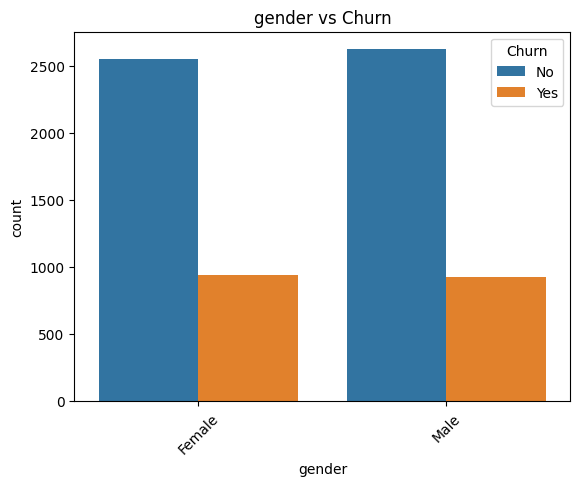

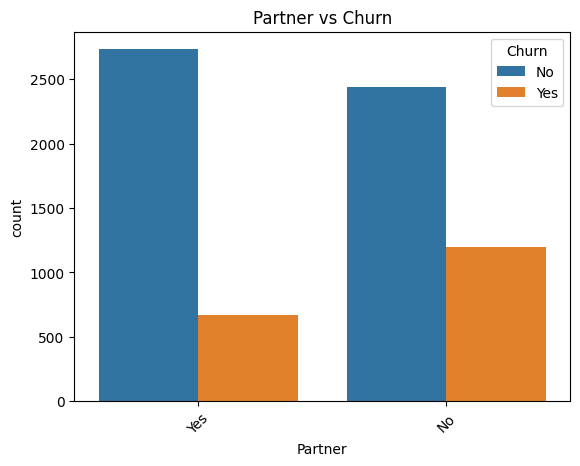

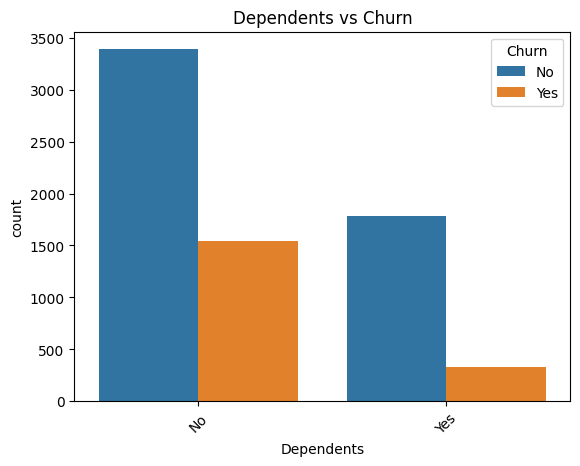

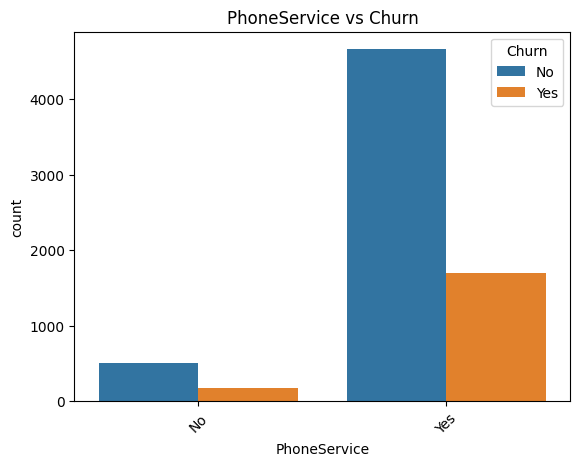

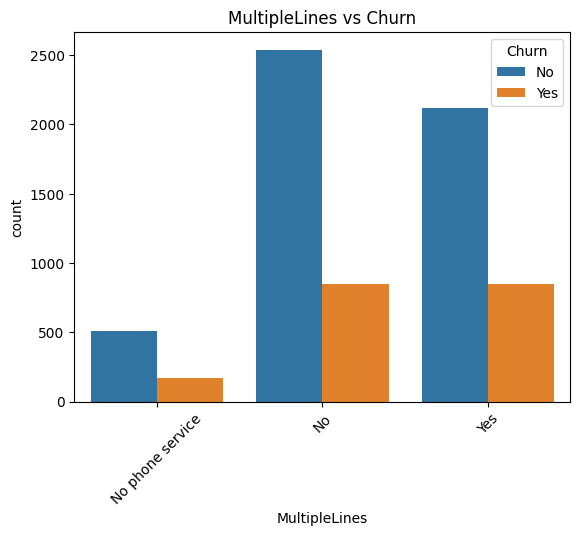

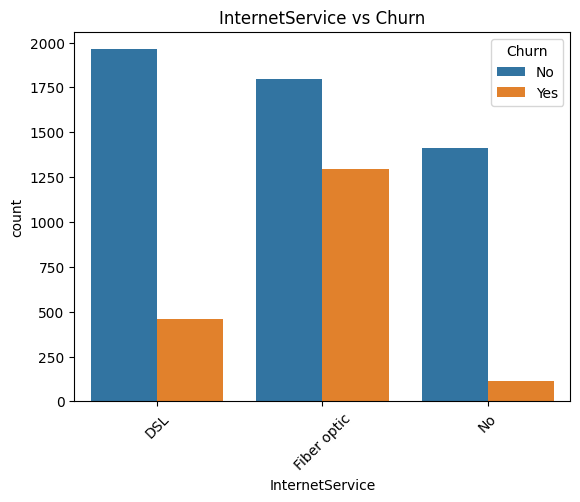

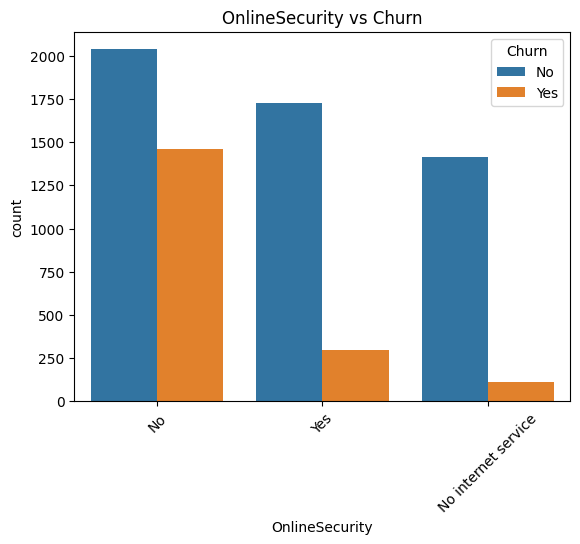

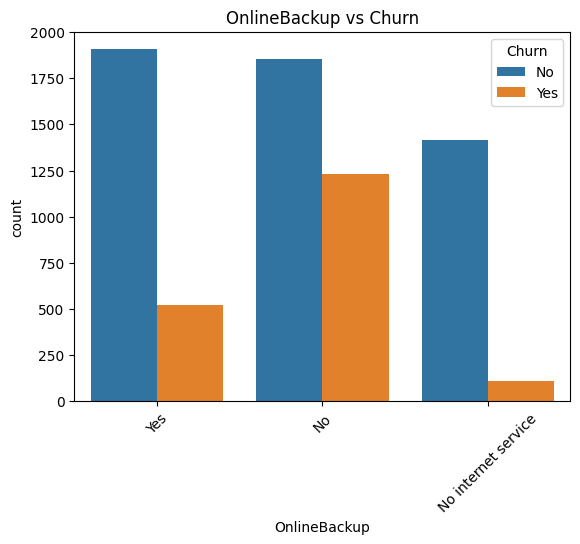

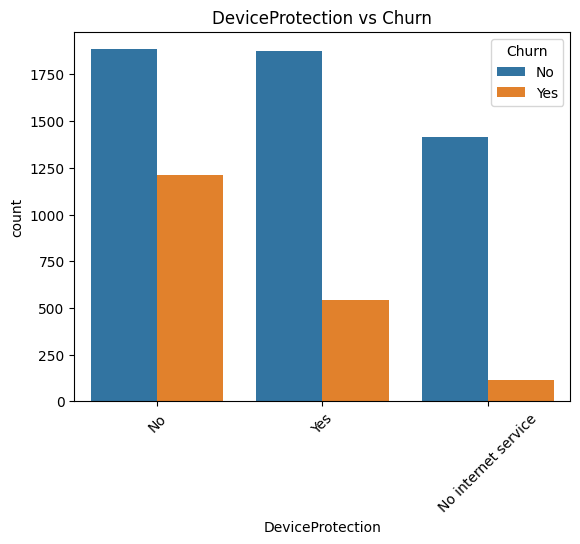

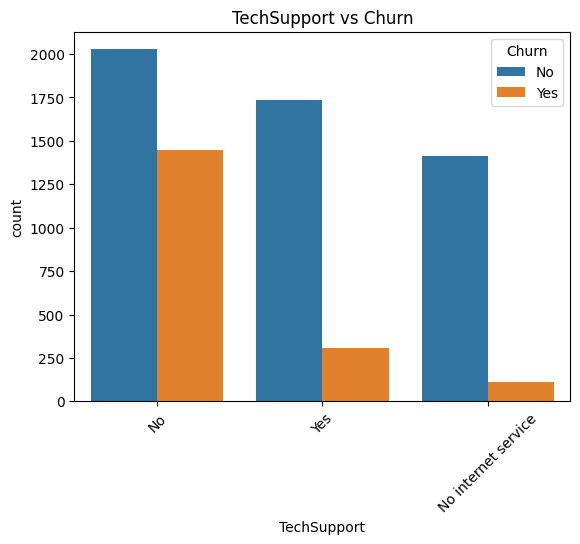

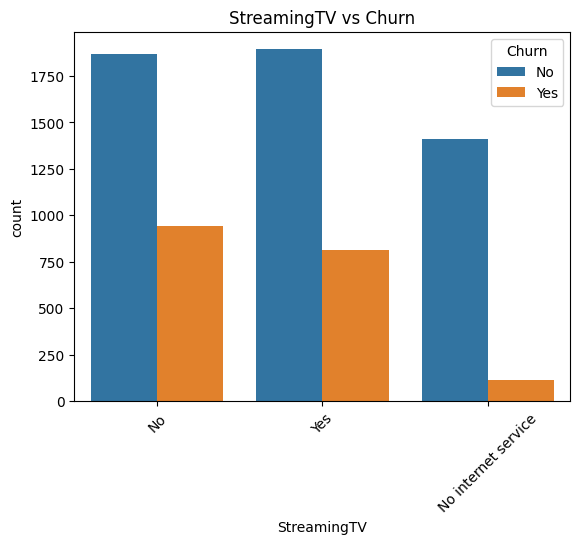

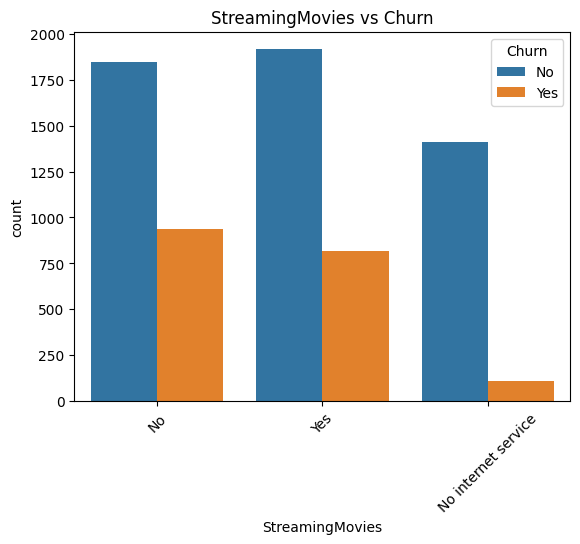

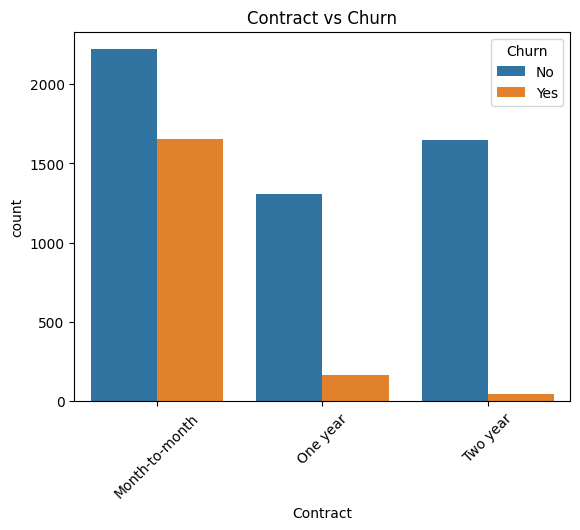

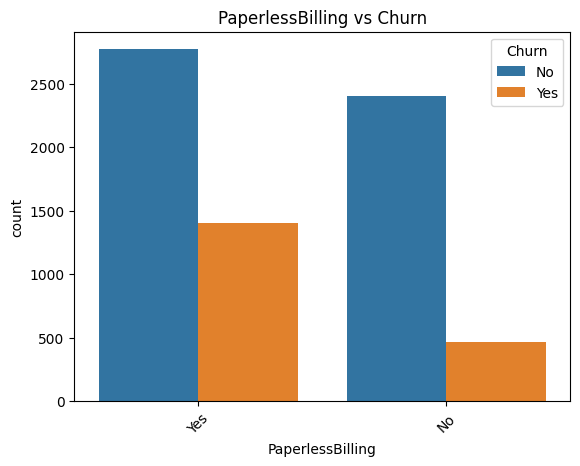

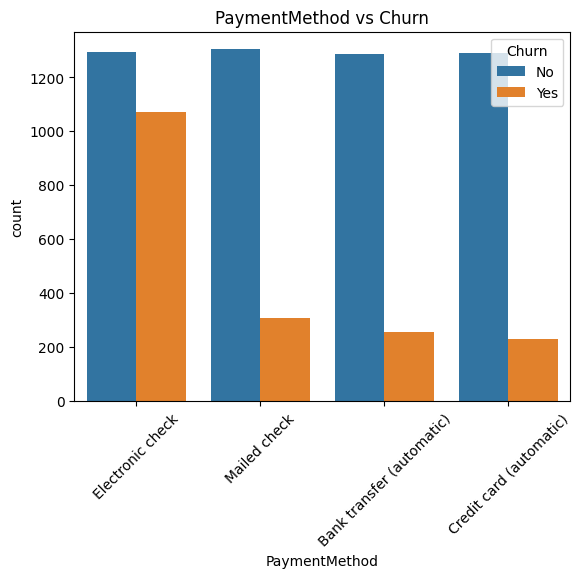

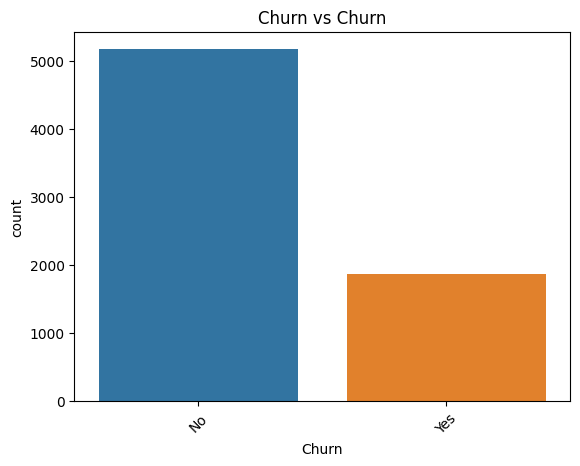

In [17]:
for col in cat_cols:
    if col != "customerID":
        plt.figure()
        sns.countplot(data=df, x=col, hue="Churn")
        plt.xticks(rotation=45)
        plt.title(f"{col} vs Churn")
        plt.show()

for col in cat_cols:
    if col != "customerID":
        plt.figure()
        sns.countplot(data=df, x=col, hue="Churn")
        plt.xticks(rotation=45)
        plt.title(f"{col} vs Churn")
        plt.show()

**Relationship Between Categorical Variables and Churn**

Categorical variables are analyzed in relation to churn using count plots.

Key Findings:
- gender
No significant differences are observed between males and females
Churn is distributed very similarly across both groups
This variable does not appear to be relevant for predicting churn
- Partner
Customers without a partner show a higher proportion of churn
Having a partner appears to be associated with greater stability and lower churn
- Dependents
Customers without dependents have a considerably higher churn rate
Having dependents seems to be an important retention factor
- PhoneService / MultipleLines
No clear differences in churn are observed with respect to these services
Their impact appears limited compared to other variables
- InternetService
Customers with fiber optic service show the highest churn rate
DSL shows lower churn
Customers without internet service show the lowest churn
This suggests potential issues related to cost or service quality in fiber
- OnlineSecurity
Customers without online security show a significantly higher churn rate
Having this service notably reduces churn
- OnlineBackup
Customers without online backup show higher churn
Additional services appear to increase retention
- DeviceProtection
Customers without device protection have higher churn
Similar to other services, it acts as a retention factor
- TechSupport
This is one of the most relevant variables
Customers without technical support show a very high churn rate
Having technical support significantly reduces churn
- StreamingTV / StreamingMovies
These do not show a clear impact on churn
Their effect appears less relevant compared to support or security services
- Contract
This is the most important variable in the analysis
"Month-to-month" contracts show a very high churn rate
One-year and two-year contracts show much higher retention
This indicates that contractual commitment is key to reducing churn
- PaperlessBilling
Customers with paperless billing show higher churn
This may be related to more digital or less committed customer profiles
- PaymentMethod
"Electronic check" shows the highest churn rate
Automatic methods (bank transfer or credit card) show lower churn
This suggests that automatic payment methods are associated with higher retention

-- Business Insight:

Customers at higher risk of churn are those who:

- Have month-to-month contracts
- Do not have additional services (security, technical support, backup)
- Use payment methods such as electronic check
- Do not have a partner or dependents
- Use fiber optic services


**Summary of Key Findings**

Based on the exploratory data analysis, relevant patterns in customer churn behavior were identified.

1. Most Influential Variables

The variables with the greatest impact on churn are:

Contract
tenure
MonthlyCharges
InternetService
TechSupport
OnlineSecurity

These variables show clear differences between customers who leave the service and those who remain.

2. Customer Profile with Higher Churn Risk

The analysis suggests that customers with a higher probability of leaving the service have the following characteristics:

Low tenure (tenure)
Month-to-month contract
High monthly charges
Use of fiber optic service
Do not have additional services (technical support, security, backup)
Use payment methods such as "Electronic check"
Do not have a partner or dependents

3. Retention Factors

The following variables appear to significantly reduce churn:

Long-term contracts (1 or 2 years)
Having technical support
Having additional services (security, backup)
Automatic payment methods (credit card or bank transfer)

4. Low-Impact Variables

Some variables do not show a significant relationship with churn:

gender
PhoneService
MultipleLines

These variables may have lower relevance in modeling.

5. Data Quality

An issue was detected in the TotalCharges variable, which contained non-numeric values.

The data type was corrected
Missing values were imputed based on business logic (tenure = 0)
6. Modeling Implications
The dataset presents class imbalance (more customers who do not churn)
Metrics such as the following should be used:
Recall
F1-score
ROC-AUC
Categorical variables will need to be transformed (encoding)
The variables identified as most relevant will be key for the model
General Conclusion

Churn is strongly influenced by the level of customer commitment (contract type), tenure, and the perceived value of the service.

Customers with lower commitment and lower integration with the company’s services show a higher probability of leaving.

This analysis provides a solid foundation for building a predictive model and designing effective retention strategies.

##4. Feature Engineering

In [18]:
df = df.drop(columns=["customerID"])

The customerID column is removed, as it is a unique identifier and does not provide useful information for the model.

In [19]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

**Variable Separation**

The dataset is divided into:

- X: independent variables (features)
- y: target variable (Churn)

In [20]:
y = y.map({"No": 0, "Yes": 1})

**Target Variable Encoding**

The Churn variable is converted into numerical format:

- 0 → customer who stays
- 1 → customer who leaves

In [21]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include="object").columns

**Identification of Variable Types**

Variables are separated into:

- Numerical variables (num_cols)
- Categorical variables (cat_cols)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Dataset Splitting**

The dataset is divided into:

- 80% training
- 20% testing

stratify=y is used to maintain the proportion of churn in both sets, which is important due to class imbalance.

In [23]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

**Preprocessing Pipeline**

A pipeline is built to transform the data before modeling:

- Numerical variables → scaled using StandardScaler
- Categorical variables → converted into dummy variables using OneHotEncoder

The ColumnTransformer allows different transformations to be applied to different types of variables in an organized and reproducible way.

## 5. Model Training and Evaluation

### 5.1 Logistic Regression

In [24]:
model_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])


model_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

**Baseline Model: Logistic Regression**

A logistic regression model is trained as a baseline.

This model is simple, interpretable, and serves as a reference point for comparing more complex models.

It is integrated into the pipeline to ensure that preprocessing is correctly applied during training.

In [25]:
y_pred_lr = model_lr.predict(X_test)

**Generating Predictions**

Predictions are generated on the test set (X_test).

These predictions will be used to evaluate the model’s performance.

In [26]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



**Interpretation:**

The baseline model shows good overall accuracy, mainly due to its ability to correctly classify the majority class (customers who do not churn).

However, the recall for the churn class is relatively low, indicating that the model fails to detect a significant proportion of at-risk customers.

In other words, the model is conservative when predicting churn, which reduces false positives but increases false negatives.

-- Business Implication

False negatives represent customers who leave the service without being detected, which has a direct impact on revenue.

Although the model is useful as a baseline, it is not ideal for retention strategies where early churn detection is a priority.

In [27]:
confusion_matrix(y_test, y_pred_lr)

array([[926, 109],
       [165, 209]])

The model correctly identifies most customers who do not churn.

However, it shows a considerable number of false negatives, indicating that many customers who leave the service are not detected.

The baseline model has good overall performance, but it is not sufficiently effective at detecting churn, which justifies the use of more advanced models or additional adjustments.

-- Business Implication

False negatives represent customers who are lost without intervention, which is critical in churn-related problems.

Reducing this value should be a priority, even if it slightly increases false positives.



### 5.2 Modelo avanzado: Random Forest

In [28]:
model_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

model_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=42))])

**Baseline Model: Random Forest**

This model is capable of capturing non-linear relationships and often provides better performance than linear models such as logistic regression.

In [29]:
y_pred_rf = model_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



**Key Interpretation:**

- Although Random Forest is a more complex model, it does not improve performance on the positive class
- A slight decrease in accuracy and overall metrics is observed
- The model continues to favor the majority class (No churn)

This suggests that:

- The problem is influenced by class imbalance
- Additional adjustments are required (tuning, class_weight, or balancing techniques)

-- Business Implications:

The Random Forest model is less effective than logistic regression at detecting customers at risk of churn.

This is problematic, as the main objective is to identify churn.



In [30]:
confusion_matrix(y_test, y_pred_rf)

array([[926, 109],
       [192, 182]])

The model performs well in identifying customers who do not churn.

However, it shows a high number of false negatives, indicating that many customers who leave the service are not detected.

In fact, the number of false negatives is higher than the number of true positives, reflecting a low capacity of the model to identify churn.

This justifies the need to apply techniques to handle class imbalance or adjust the model.

-- Business Implication:

False negatives represent customers who are lost without intervention, which is critical in churn-related problems.

This behavior limits the usefulness of the model in retention scenarios.



In [31]:
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, y_proba_rf)

np.float64(0.8185099072567104)

Despite a good ROC-AUC, the model shows low recall for the churn class when using the default threshold (0.5).

This indicates that, although the model is capable of separating the classes, it is not properly optimizing churn detection under the current configuration.

The model has strong potential, but it requires adjustments (such as class balancing or modifying the decision threshold) to be useful in a business context.

## 6. Model Tuning

### 6.1 Logistic Regression

In [32]:
model_lr_balanced = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model_lr_balanced.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

**Model Evaluation: Balanced Logistic Regression**

A logistic regression model is trained using class_weight="balanced" to give more weight to the minority class (Churn).

In [33]:
y_pred_lr_bal = model_lr_balanced.predict(X_test)

print(classification_report(y_test, y_pred_lr_bal))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



**Interpretation:**

The balanced model significantly improves the detection of customers who churn.

The churn recall increases from 0.56 to 0.78
The model now detects a much higher proportion of at-risk customers
The cost of this improvement is a reduction in precision and accuracy

This means that the model generates more false positives, but misses fewer customers who actually leave the service.

-- Business Implicatio
In churn-related problems, this behavior can be desirable, as it is usually more costly to fail to detect an at-risk customer than to contact a customer who was not actually going to leave.

For this reason, the balanced model represents a significant improvement over the baseline when the main objective is retention.

In [34]:
model_rf_bal = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_estimators=200,
        max_depth=10
    ))
])

model_rf_bal.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_estimators=200, random_state=42))])

**Model Evaluation: Balanced Random Forest**

A Random Forest model is trained considering class imbalance using class_weight="balanced".

In [35]:
y_pred_rf_bal = model_rf_bal.predict(X_test)

print(classification_report(y_test, y_pred_rf_bal))

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1035
           1       0.55      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



**Interpretation:**

The balanced Random Forest model shows a significant improvement compared to its unadjusted version.

Churn recall increases from 0.49 to 0.71
The F1-score improves to 0.62, making it the best among all evaluated models
It maintains a good balance between precision and recall

This indicates that the model better captures the complexity of the problem without losing too much stability.

Although the balanced logistic regression has higher recall, Random Forest offers a more balanced performance, making it the most robust model for this problem.

-- Business Implications

The model is able to detect a considerable proportion of at-risk customers (71%) without generating a critical excess of false positives.

This makes it a strong option when seeking a balance between effectiveness and operational cost.



## 7. Model Packaging

In [36]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(model_rf_bal, "models/churn_pipeline.joblib")

print("Template saved successfully")

Template saved successfully


After selecting the best performing model (Random Forest with class balancing), the final step is to package the model for reuse in inference scenarios.

Instead of keeping preprocessing and modeling steps separated, the full pipeline is saved as a single artifact. This ensures that any new data passed to the model will go through the exact same transformations used during training.

This approach improves reproducibility, reduces the risk of errors, and allows the model to be easily integrated into external systems such as APIs or cloud services.

## 7. Conclusions

This project focused on predicting customer churn using machine learning techniques, combining exploratory data analysis, feature engineering, and model evaluation.

Several models were evaluated, including Logistic Regression and Random Forest, both in their baseline and class-balanced versions.

The main findings are:

- Customer churn is strongly associated with tenure, contract type, and monthly charges
- Customers with short tenure and month-to-month contracts show higher churn rates
- Class imbalance significantly affects model performance and must be addressed
- Applying class_weight="balanced improves the model’s ability to detect churn

The final selected model was a Random Forest with class balancing, as it provided the best trade-off between precision, recall, and F1-score.

Although Logistic Regression achieved higher recall in some configurations, Random Forest demonstrated a more stable and robust overall performance.

From a business perspective, improving recall is critical, as failing to detect churn can lead to direct revenue loss.

## 8. Limitations

Despite achieving reasonable performance, this project has several limitations:

- The dataset is relatively small and may not fully represent real-world variability
- No hyperparameter tuning (e.g., GridSearch or RandomizedSearch) was applied
- Threshold optimization was explored but not implemented as part of the final model
- No advanced models (e.g., Gradient Boosting, XGBoost, LightGBM) were evaluated
- Feature engineering was limited and could be further expanded
- The model does not incorporate temporal behavior or customer lifecycle dynamics
- No cost-sensitive evaluation was applied (e.g., business cost of false positives vs false negatives)

Additionally, the model was evaluated on a static dataset and does not account for real-time data drift.

## 9. Next Steps

To improve this project and move closer to a production-ready system, the following steps are recommended:

### Model Improvement
- Perform hyperparameter tuning for Random Forest
- Evaluate more advanced models such as XGBoost or LightGBM
- Apply threshold optimization based on business objectives
- Explore calibration of predicted probabilities

### Data & Features
- Perform deeper feature engineering
- Incorporate behavioral or temporal features
- Handle potential data drift scenarios

### MLOps & Deployment
- Exposing the model through a FastAPI endpoint
- Validating predictions with structured JSON inputs
- Deploy the model using AWS services (e.g., SageMaker, Lambda, or API Gateway)
- Create an inference pipeline for real-time predictions
- Implement monitoring for model performance and drift
- Automate retraining workflows

### Business Integration
- Define a cost function aligned with churn impact
- Integrate the model into a retention strategy system
- Evaluate ROI of retention campaigns based on model predictions